<a href="https://colab.research.google.com/github/vyron-arvanitis/pytorch_tutorials/blob/main/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Workflow

In [ ]:
what_is_covered = {1: "data (prepare and load)",
                   2: "build model",
                   3: "fit",
                   4: "make predictions and evaluate",
                   5: "save and load the model",
                   6: "putting it all together"}
what_is_covered

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fit',
 4: 'make predictions and evaluate',
 5: 'save and load the model',
 6: 'putting it all together'}

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

# PyTorch version
torch.__version__

'2.9.0+cpu'

## 1. Data (prepare and load)


In [ ]:
# Create Data using linear regression
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
len(X), len(y)

(50, 50)

### Split data into train, test,  split

In [ ]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

Visualize data!

In [ ]:
def plot_predictions(train_data=X_train,
                    train_labels=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                     predictions=None):
  plt.figure(figsize=(10, 7))

  # Plot training data in  lbue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # PLot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  # Predictions?
  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  plt.legend(prop={"size": 14})



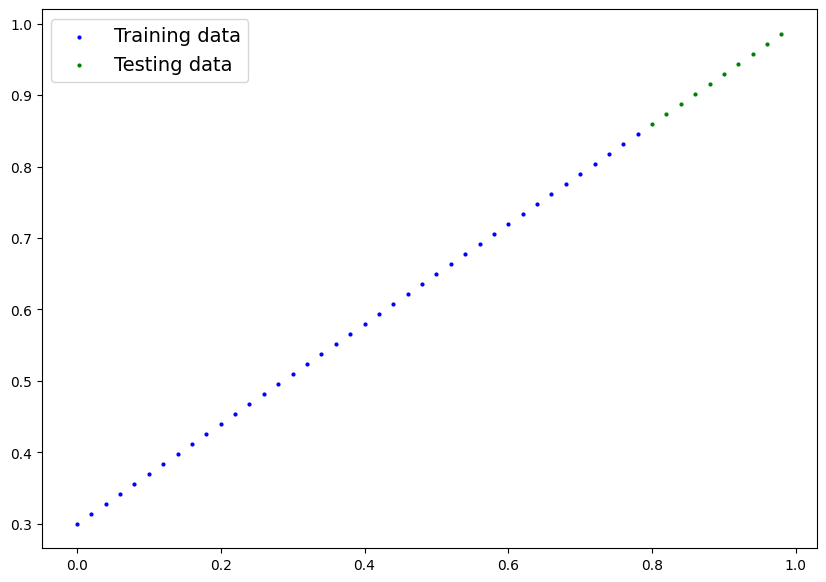

In [ ]:
plot_predictions()

## 2. Build Model

In [ ]:
# Create linear regression model class
class LinearRegressionModel(nn.Module):

  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.rand(1,
                                           requires_grad=True,
                                            dtype=torch.float))
    self.bias = nn.Parameter(torch.rand(1,
                                        requires_grad=True,
                                        dtype=torch.float))

    def forward(self, x:torch.Tensor) -> torch.Tensor:
      return self.weights * x + self.bias

### PyTorch model building essentials

* torch.nn -> all buidling blocks
* torch.nn.Parameter
* torch.nn.Module -> base calss for all neural network modules
* torch.optim -> optimizers of PyTorch
* def forward() -> @abstractmethod of nn.Module

In [ ]:
# Create a random seed

torch.manual_seed(42)

# Create an instance of the model
model_0 = LinearRegressionModel()
print(model_0.parameters()) # this is a generator-> turn it into a list
print(list(model_0.parameters()))

<generator object Module.parameters at 0x7be53d54f680>
[Parameter containing:
tensor([0.8823], requires_grad=True), Parameter containing:
tensor([0.9150], requires_grad=True)]


In [ ]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [ ]:
torch.rand(2)

tensor([0.5936, 0.8694])

### Make prediction using `torch.inference_mode()`